# Multi-Agent Collaboration Experiments

**AI Trader Pro — Light copy-trade simulation**

Simple experiment:
- 5 synthetic agents with different return profiles
- 1 leader, 3 followers with copy lag
- Compare solo vs copy-trade performance
- Correlation matrix + bar chart

## 1. Setup

In [1]:
%matplotlib inline

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252
SEED = 42
rng = np.random.default_rng(SEED)

plt.style.use('seaborn-v0_8-darkgrid')
print('Setup complete.')

Setup complete.


## 2. Simulate Agent Returns

In [2]:
agents = {
    'MomentumBot': {'mu': 0.0008, 'sigma': 0.012, 'style': 'trend'},
    'MeanReversionAgent': {'mu': 0.0004, 'sigma': 0.008, 'style': 'mean-rev'},
    'SentimentTrader': {'mu': 0.0003, 'sigma': 0.018, 'style': 'sentiment'},
    'RiskParityAI': {'mu': 0.0005, 'sigma': 0.006, 'style': 'risk-parity'},
    'AggressiveAlpha': {'mu': 0.0010, 'sigma': 0.022, 'style': 'aggressive'},
}

dates = pd.bdate_range('2024-01-01', periods=TRADING_DAYS)
returns = pd.DataFrame(index=dates)

for name, params in agents.items():
    returns[name] = rng.normal(params['mu'], params['sigma'], TRADING_DAYS)

returns.head()

,MomentumBot,MeanReversionAgent,SentimentTrader,RiskParityAI,AggressiveAlpha
2024-01-01,0.004457,0.014230,-0.053062,-0.005025,0.017637
2024-01-02,-0.011680,-0.007495,-0.009483,0.005630,0.009335
2024-01-03,0.009805,-0.001562,0.043867,0.004338,-0.026166
2024-01-04,0.012087,0.006619,0.008128,0.003155,0.032731
2024-01-05,-0.022612,0.003878,-0.009772,0.007998,-0.010016


## 3. Copy-Trade Simulation

In [3]:
LEADER = 'MomentumBot'
FOLLOWERS = ['MeanReversionAgent', 'SentimentTrader', 'RiskParityAI']
COPY_LAG = 1          # days delay before follower mirrors leader
COPY_WEIGHT = 0.6     # fraction of leader signal copied
NOISE = 0.003         # follower execution noise

adjusted = returns.copy()
leader_signal = returns[LEADER].shift(COPY_LAG).fillna(0)

for follower in FOLLOWERS:
    own = returns[follower]
    copied = COPY_WEIGHT * leader_signal + (1 - COPY_WEIGHT) * own
    copied += rng.normal(0, NOISE, TRADING_DAYS)
    adjusted[f'{follower}_copy'] = copied
    adjusted[f'{follower}_solo'] = own

print(f'Leader: {LEADER} | Followers: {FOLLOWERS}')
adjusted.filter(like='_copy').head()

Leader: MomentumBot | Followers: ['MeanReversionAgent', 'SentimentTrader', 'RiskParityAI']


,MeanReversionAgent_copy,SentimentTrader_copy,RiskParityAI_copy
2024-01-01,0.008690,-0.018538,-0.005166
2024-01-02,-0.000032,-0.007112,0.004493
2024-01-03,-0.005245,0.005492,-0.008923
2024-01-04,0.007189,0.009765,0.009672
2024-01-05,0.008655,0.001199,0.007698


## 4. Performance Comparison

In [4]:
def quick_metrics(daily_rets: pd.Series) -> dict[str, float]:
    equity = (1 + daily_rets).cumprod()
    peak = equity.cummax()
    dd = (equity - peak) / peak
    sharpe = np.sqrt(TRADING_DAYS) * daily_rets.mean() / daily_rets.std() if daily_rets.std() else 0
    return {
        'total_return': float(equity.iloc[-1] - 1),
        'sharpe': float(sharpe),
        'max_drawdown': float(dd.min()),
        'volatility': float(daily_rets.std() * np.sqrt(TRADING_DAYS)),
    }

rows = []
for col in adjusted.columns:
    m = quick_metrics(adjusted[col])
    m['agent'] = col
    rows.append(m)

perf = pd.DataFrame(rows).set_index('agent')
perf.style.format({'total_return': '{:.2%}', 'sharpe': '{:.3f}', 'max_drawdown': '{:.2%}', 'volatility': '{:.2%}'})

,total_return,sharpe,max_drawdown,volatility
agent,,,,
MomentumBot,4.03%,0.310,-12.02%,17.86%
MeanReversionAgent,14.83%,1.167,-9.45%,12.52%
SentimentTrader,-32.76%,-1.191,-44.49%,29.63%
RiskParityAI,13.95%,1.442,-8.94%,9.37%
AggressiveAlpha,10.75%,0.467,-31.66%,34.85%
MeanReversionAgent_copy,9.42%,0.743,-9.93%,13.29%
MeanReversionAgent_solo,14.83%,1.167,-9.45%,12.52%
SentimentTrader_copy,-21.94%,-1.403,-27.90%,16.66%
SentimentTrader_solo,-32.76%,-1.191,-44.49%,29.63%


## 5. Solo vs Copy-Trade

In [5]:
comparison_rows = []
for follower in FOLLOWERS:
    solo = perf.loc[f'{follower}_solo']
    copy = perf.loc[f'{follower}_copy']
    comparison_rows.append(
        {
            'follower': follower,
            'solo_sharpe': solo['sharpe'],
            'copy_sharpe': copy['sharpe'],
            'sharpe_delta': copy['sharpe'] - solo['sharpe'],
            'solo_return': solo['total_return'],
            'copy_return': copy['total_return'],
        }
    )

comparison = pd.DataFrame(comparison_rows)
comparison.style.format(
    {
        'solo_sharpe': '{:.3f}',
        'copy_sharpe': '{:.3f}',
        'sharpe_delta': '{:+.3f}',
        'solo_return': '{:.2%}',
        'copy_return': '{:.2%}',
    }
)

,follower,solo_sharpe,copy_sharpe,sharpe_delta,solo_return,copy_return
0,MeanReversionAgent,1.167,0.743,-0.424,14.83%,9.42%
1,SentimentTrader,-1.191,-1.403,-0.213,-32.76%,-21.94%
2,RiskParityAI,1.442,-0.224,-1.666,13.95%,-3.33%


## 6. Correlation & Visualizations

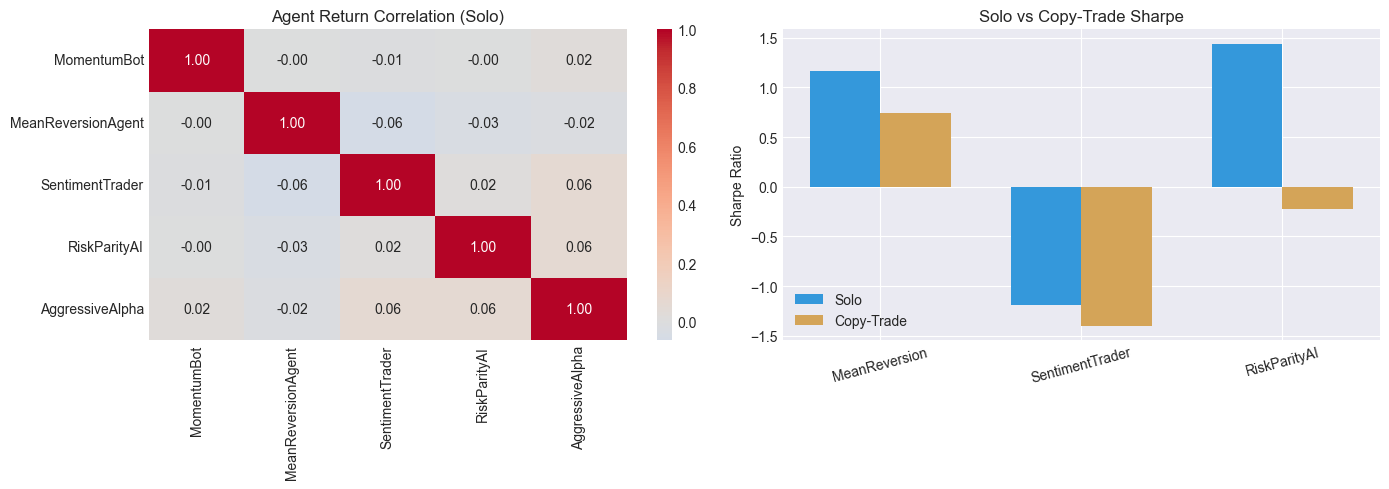

Saved figures/multi_agent_collaboration.png


In [6]:
corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Agent Return Correlation (Solo)')

x = np.arange(len(comparison))
width = 0.35
axes[1].bar(x - width / 2, comparison['solo_sharpe'], width, label='Solo', color='#3498db')
axes[1].bar(x + width / 2, comparison['copy_sharpe'], width, label='Copy-Trade', color='#d4a458')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f.split('Agent')[0] for f in FOLLOWERS], rotation=15)
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('Solo vs Copy-Trade Sharpe')
axes[1].legend()

plt.tight_layout()
collab_path = FIGURES_DIR / 'multi_agent_collaboration.png'
plt.savefig(collab_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {collab_path}')

## 7. Conclusions

In [7]:
improved = comparison[comparison['sharpe_delta'] > 0]
worse = comparison[comparison['sharpe_delta'] <= 0]

print('=' * 55)
print('MULTI-AGENT COLLABORATION — SUMMARY')
print('=' * 55)
print(f'Leader agent          : {LEADER}')
print(f'Followers tested      : {len(FOLLOWERS)}')
print(f'Copy improved Sharpe  : {len(improved)} / {len(FOLLOWERS)} followers')
if not improved.empty:
    best = improved.loc[improved['sharpe_delta'].idxmax()]
    print(f'Best follower gain    : {best["follower"]} ({best["sharpe_delta"]:+.3f} Sharpe)')
print(f'\nAvg solo Sharpe       : {comparison["solo_sharpe"].mean():.3f}')
print(f'Avg copy Sharpe       : {comparison["copy_sharpe"].mean():.3f}')
print(f'\nInterpretation: copy-trading helps when leader alpha > follower noise.')
print(f'High correlation ({float(corr[LEADER].drop(LEADER, errors="ignore").mean()):.2f} avg) → limited diversification benefit.')

MULTI-AGENT COLLABORATION — SUMMARY
Leader agent          : MomentumBot
Followers tested      : 3
Copy improved Sharpe  : 0 / 3 followers

Avg solo Sharpe       : 0.473
Avg copy Sharpe       : -0.295

Interpretation: copy-trading helps when leader alpha > follower noise.
High correlation (0.00 avg) → limited diversification benefit.
